# Imports and Setup

In [140]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Add, Dense, Activation, BatchNormalization, Conv2D, AveragePooling2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import math
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

import os

In [141]:
print("Num GPUs Available:", len(tf.config.experimental.list_physical_devices('GPU')))

Num GPUs Available: 1


In [142]:
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/usr/local/cuda"
os.environ["MLIR_CRASH_REPRODUCER_DIRECTORY"] = ""
os.environ["CUDA_COMPAT"] = "1"

In [143]:
tf.get_logger().setLevel("ERROR")

In [144]:
# Define constants
TFRECORD_FILE = "../shared/filtered_emnist.tfrecord"

BATCH_SIZE = 64
IMG_SIZE = (28, 28)
NUM_CLASSES = 36  # Digits (0-9) + Uppercase Letters (A-Z)
EPOCHS = 20

TOTAL_SAMPLES = 533993
TRAIN_RATIO = 0.8
TRAIN_SIZE = int(TOTAL_SAMPLES * TRAIN_RATIO)
VAL_SIZE = TOTAL_SAMPLES - TRAIN_SIZE

# Label dictionary
label_dict = {
    0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9',
    10: 'A', 11: 'B', 12: 'C', 13: 'D', 14: 'E', 15: 'F', 16: 'G', 17: 'H', 18: 'I', 19: 'J',
    20: 'K', 21: 'L', 22: 'M', 23: 'N', 24: 'O', 25: 'P', 26: 'Q', 27: 'R', 28: 'S', 29: 'T',
    30: 'U', 31: 'V', 32: 'W', 33: 'X', 34: 'Y', 35: 'Z'
}

# Helper Functions

## Data Loading

In [145]:
def visualize_dataset_samples(dataset, num_samples=20):
    """
    Visualizes a few data samples from the dataset.

    Args:
        dataset (tf.data.Dataset): The dataset containing image-label pairs.
        label_dict (dict): Dictionary mapping label indices to characters.
        num_samples (int): Number of samples to visualize (default: 20).
    """
    plt.figure(figsize=(12, 8))
    for i, (image, label) in enumerate(dataset.take(num_samples)):
        label_np = label.numpy()

        # Check if the label is one-hot encoded (array) or a single integer
        if label_np.ndim > 0 and len(label_np) > 1:
            label_index = np.argmax(label_np)  # Convert one-hot encoding to class index
        else:
            label_index = int(label_np)  # Use integer directly

        label_char = label_dict[label_index]  # Get character label

        plt.subplot(4, 5, i + 1)
        plt.imshow(image.numpy())
        plt.title(f'Label: {label_char} (Index: {label_index})', fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [146]:
# Function to parse TFRecord file
def _parse_function(proto):
    keys_to_features = {
        "image": tf.io.FixedLenFeature([], tf.string),
        "label": tf.io.FixedLenFeature([1], tf.int64)
    }
    parsed_features = tf.io.parse_single_example(proto, keys_to_features)
    image = tf.image.decode_jpeg(parsed_features["image"])
    label = parsed_features["label"][0]

    return image, label

In [147]:
def load_data():
    dataset = tf.data.TFRecordDataset(TFRECORD_FILE).map(_parse_function)
    return dataset

## Data Preprocessing

In [148]:
# Preprocess function: reshape, normalize, one-hot encode
def preprocess_data(image, label):
    image = tf.image.resize(image, IMG_SIZE) / 255.0  # Normalize pixel values
    label = tf.one_hot(label, NUM_CLASSES)  # One-hot encode labels
    return image, label

# Augmentation function
def augment_image(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    return image, label

In [149]:
def preprocess_and_split(dataset):
    # Preprocess data
    dataset = dataset.map(preprocess_data)
    
    # Split data into train and validation sets
    dataset = dataset.shuffle(1000)  # Shuffle before splitting
    
    # Apply augmentation to train dataset
    train_dataset = dataset.take(TRAIN_SIZE).map(augment_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    val_dataset = dataset.skip(TRAIN_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return dataset, train_dataset, val_dataset

## Model Definition and Initialization

In [150]:
def identity_block(x, filters, block_name):
    """Identity block for ResNet18."""
    x_shortcut = x

    # First convolution
    x = Conv2D(filters, (3, 3), padding="same", name=f"{block_name}_conv1")(x)
    x = BatchNormalization(name=f"{block_name}_bn1")(x)
    x = Activation("relu", name=f"{block_name}_relu1")(x)

    # Second convolution
    x = Conv2D(filters, (3, 3), padding="same", name=f"{block_name}_conv2")(x)
    x = BatchNormalization(name=f"{block_name}_bn2")(x)

    # Skip connection
    x = Add(name=f"{block_name}_add")([x, x_shortcut])
    x = Activation("relu", name=f"{block_name}_relu2")(x)

    return x

def convolutional_block(x, filters, strides=(2, 2), block_name="conv_block"):
    """Residual block with downsampling."""
    x_shortcut = Conv2D(filters, (1, 1), strides=strides, padding="same", name=f"{block_name}_shortcut")(x)
    x_shortcut = BatchNormalization(name=f"{block_name}_bn_shortcut")(x_shortcut)

    # First convolution (applies stride)
    x = Conv2D(filters, (3, 3), strides=strides, padding="same", name=f"{block_name}_conv1")(x)
    x = BatchNormalization(name=f"{block_name}_bn1")(x)
    x = Activation("relu", name=f"{block_name}_relu1")(x)

    # Second convolution (no stride)
    x = Conv2D(filters, (3, 3), padding="same", name=f"{block_name}_conv2")(x)
    x = BatchNormalization(name=f"{block_name}_bn2")(x)

    # Skip connection
    x = Add(name=f"{block_name}_add")([x, x_shortcut])
    x = Activation("relu", name=f"{block_name}_relu2")(x)

    return x

def ResNet18(input_shape=(28, 28, 1), num_classes=NUM_CLASSES):
    inputs = Input(shape=input_shape, name="input_layer")

    # Initial Conv Layer
    x = Conv2D(64, (5, 5), strides=2, padding="same", activation="relu", name="initial_conv")(inputs)
    x = BatchNormalization(name="initial_bn")(x)
    x = MaxPooling2D((3, 3), strides=2, padding="same", name="initial_pool")(x)

    # ResNet Blocks
    x = identity_block(x, 64, block_name="block1_1")
    x = identity_block(x, 64, block_name="block1_2")

    x = convolutional_block(x, 128, block_name="block2_1")  # Downsampling here
    x = identity_block(x, 128, block_name="block2_2")

    x = convolutional_block(x, 256, block_name="block3_1")  # Downsampling here
    x = identity_block(x, 256, block_name="block3_2")

    x = convolutional_block(x, 512, block_name="block4_1")  # Downsampling here
    x = identity_block(x, 512, block_name="block4_2")

    # Classification Head
    x = GlobalAveragePooling2D(name="global_avg_pool")(x)
    outputs = Dense(num_classes, activation="softmax", name="output_layer")(x)

    model = Model(inputs, outputs, name="ResNet18")
    return model

In [151]:
def init_model():
    # Initialize ResNet18 model
    model = ResNet18()
    
    # Compile model
    model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Summarize model
    model.summary()

    return model

## Model Training

In [167]:
def train_model(model):    
    # Checkpoint to save the best model
    model_checkpoint = ModelCheckpoint('resnet18.keras', monitor='val_accuracy', mode='max', save_best_only=False, verbose=1)
    
    # Early stopping to prevent overfitting
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    # Reduce learning rate when validation loss plateaus
    lr_scheduler = ReduceLROnPlateau(
        monitor='val_loss',  # Watch validation loss
        factor=0.5,          # Reduce LR by half
        patience=3,          # Wait 3 epochs before reducing
        verbose=1,           # Print updates
        min_lr=1e-6          # Set a lower bound for LR
    )
    
    # Train the model
    model_history = model.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS, callbacks=[model_checkpoint, early_stopping, lr_scheduler])
    
    # Save model
    # model.save("resnet18_final.keras")

    return model_history

## Model Evaluation

In [153]:
def plot_accuracy_loss(model_history):
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    # Extract relevant metrics
    accuracy = model_history.history.get("accuracy", [])
    val_accuracy = model_history.history.get("val_accuracy", [])
    loss = model_history.history.get("loss", [])
    val_loss = model_history.history.get("val_loss", [])

    epochs = range(1, len(accuracy) + 1)

    # Accuracy subplot
    ax[0].plot(epochs, accuracy, label="Training Accuracy", marker="o")
    ax[0].plot(epochs, val_accuracy, label="Validation Accuracy", marker="s")
    ax[0].set_title("Model Accuracy")
    ax[0].set_xlabel("Epochs")
    ax[0].set_ylabel("Accuracy")
    ax[0].legend()
    ax[0].grid(True, linestyle="--", alpha=0.6)

    # Annotate first and last points
    if accuracy:
        ax[0].text(1, accuracy[0], f"{accuracy[0]:.4f}", fontsize=10, ha='left', va='top')
        ax[0].text(epochs[-1], accuracy[-1], f"{accuracy[-1]:.4f}", fontsize=10, ha='left', va='bottom')
    if val_accuracy:
        ax[0].text(1, val_accuracy[0], f"{val_accuracy[0]:.4f}", fontsize=10, ha='left', va='top', color="blue")
        ax[0].text(epochs[-1], val_accuracy[-1], f"{val_accuracy[-1]:.4f}", fontsize=10, ha='left', va='top', color="blue")

    # Loss subplot
    ax[1].plot(epochs, loss, label="Training Loss", marker="o")
    ax[1].plot(epochs, val_loss, label="Validation Loss", marker="s")
    ax[1].set_title("Model Loss")
    ax[1].set_xlabel("Epochs")
    ax[1].set_ylabel("Loss")
    ax[1].legend()
    ax[1].grid(True, linestyle="--", alpha=0.6)

    # Annotate first and last points
    if loss:
        ax[1].text(1, loss[0], f"{loss[0]:.4f}", fontsize=10, ha='left', va='bottom')
        ax[1].text(epochs[-1], loss[-1], f"{loss[-1]:.4f}", fontsize=10, ha='left', va='top')
    if val_loss:
        ax[1].text(1, val_loss[0], f"{val_loss[0]:.4f}", fontsize=10, ha='left', va='bottom', color="blue")
        ax[1].text(epochs[-1], val_loss[-1], f"{val_loss[-1]:.4f}", fontsize=10, ha='left', va='top', color="blue")

    plt.tight_layout()
    plt.show()

In [154]:
def extract_predictions(model, dataset, num_samples=20):
    y_true = []
    y_pred = []
    sample_images = []
    sample_labels = []
    sample_preds = []

    for images, labels in dataset:
        # Convert one-hot encoded labels to class indices
        y_true.append(np.argmax(labels, axis=1))
        
        preds = model.predict(images, verbose=0)
        y_pred.append(np.argmax(preds, axis=1))

        # Store a sample images with predictions
        if len(sample_images) < num_samples:
            for i in range(min(len(images), num_samples - len(sample_images))):
                sample_images.append(images[i].numpy())
                sample_labels.append(np.argmax(labels[i].numpy()))
                sample_preds.append(np.argmax(preds[i]))

    # Concatenate all batches into single arrays
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    return y_true, y_pred, sample_images, sample_labels, sample_preds

In [155]:
def compute_metrics(y_true, y_pred, class_names):
    # Compute precision, recall, and F1-score
    precision = precision_score(y_true, y_pred, average="macro", zero_division=1)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=1)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=1)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(16, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=[class_names[i] for i in sorted(class_names.keys())],
                yticklabels=[class_names[i] for i in sorted(class_names.keys())])
    plt.title('Confusion Matrix', fontsize=18)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [156]:
def plot_sample_predictions(sample_images, sample_labels, sample_preds, class_names, num_samples=20):
    plt.figure(figsize=(12, 8))
    for i in range(num_samples):
        plt.subplot(4, 5, i + 1)
        plt.imshow(sample_images[i])
        plt.title(f"Pred: {class_names[sample_preds[i]]} (Index: {sample_preds[i]})\n"
                  f"True: {class_names[sample_labels[i]]} (Index: {sample_labels[i]})", fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Load Data

In [157]:
# Load dataset
dataset = load_data()

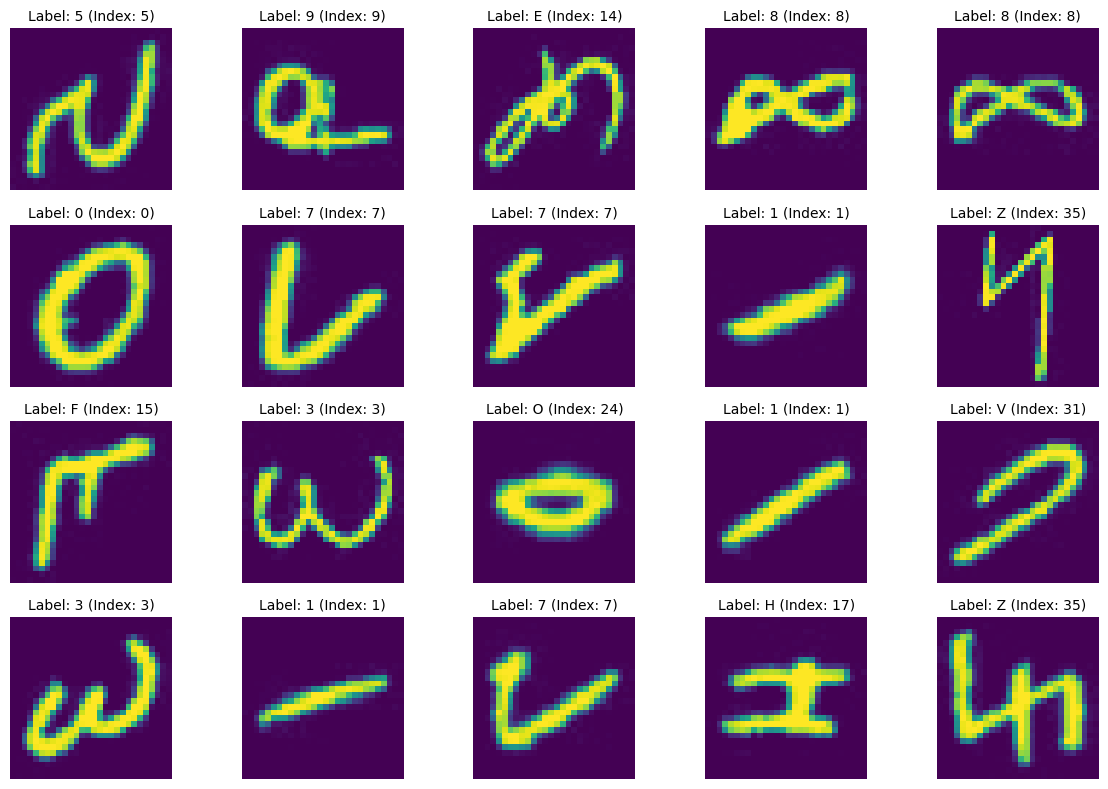

In [158]:
visualize_dataset_samples(dataset, num_samples=20)

# Data Preprocessing

In [159]:
dataset, train_dataset, val_dataset = preprocess_and_split(dataset)

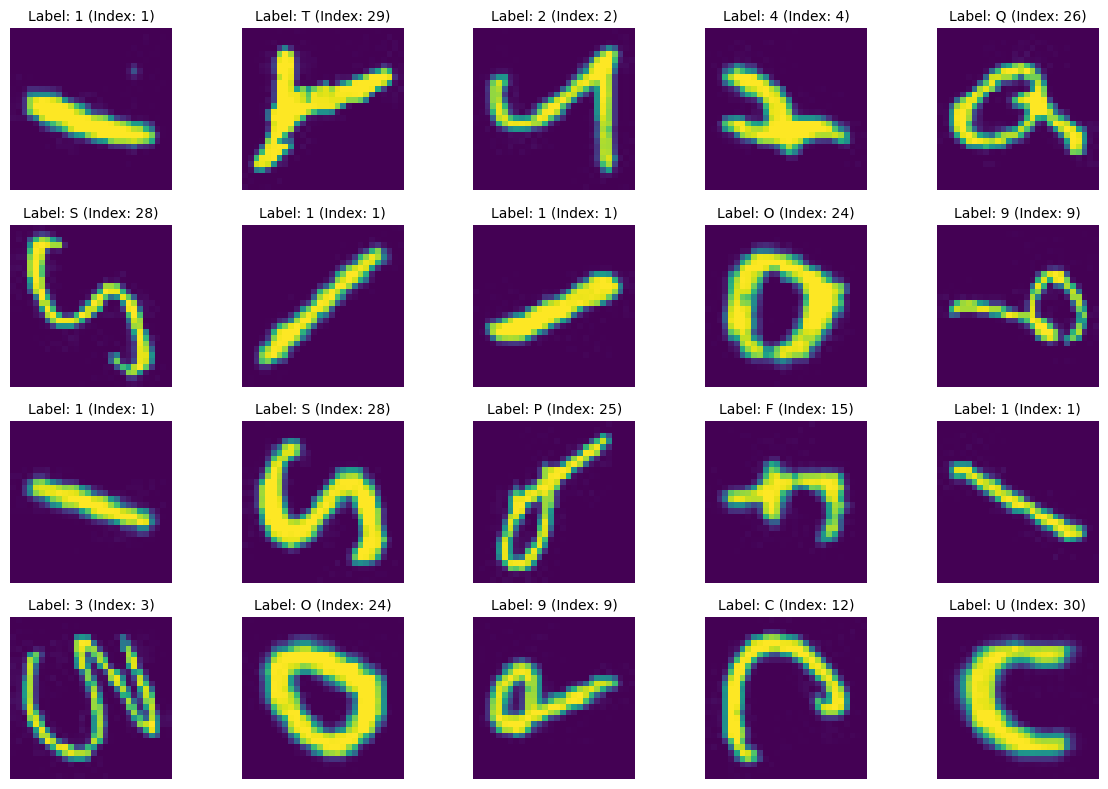

In [160]:
visualize_dataset_samples(train_dataset.unbatch(), num_samples=20)

# Train Model

In [161]:
model = init_model()

Model: "ResNet18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_conv        │ (None, 14, 14,    │      1,664 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_bn          │ (None, 14, 14,    │        256 │ initial_conv[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_pool        │ (None, 7, 7, 64)  │          0 │ initial_bn[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_conv1      │ (None, 7, 7, 64)  │     36,928 │ initial_pool[0][… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_bn1        │ (None, 7, 7, 64)  │        256 │ block1_1_conv1[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_relu1      │ (None, 7, 7, 64)  │          0 │ block1_1_bn1[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_conv2      │ (None, 7, 7, 64)  │     36,928 │ block1_1_relu1[0… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_bn2        │ (None, 7, 7, 64)  │        256 │ block1_1_conv2[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_add (Add)  │ (None, 7, 7, 64)  │          0 │ block1_1_bn2[0][… │
│                     │                   │            │ initial_pool[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_relu2      │ (None, 7, 7, 64)  │          0 │ block1_1_add[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_conv1      │ (None, 7, 7, 64)  │     36,928 │ block1_1_relu2[0… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_bn1        │ (None, 7, 7, 64)  │        256 │ block1_2_conv1[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_relu1      │ (None, 7, 7, 64)  │          0 │ block1_2_bn1[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_conv2      │ (None, 7, 7, 64)  │     36,928 │ block1_2_relu1[0… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_bn2        │ (None, 7, 7, 64)  │        256 │ block1_2_conv2[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_add (Add)  │ (None, 7, 7, 64)  │          0 │ block1_2_bn2[0][

 Total params: 11,201,572 (42.73 MB)

 Trainable params: 11,191,972 (42.69 MB)

 Non-trainable params: 9,600 (37.50 KB)

In [162]:
model_history = train_model(model)

Epoch 1/20
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 164s 22ms/step - accuracy: 0.8030 - loss: 0.6324 - val_accuracy: 0.9050 - val_loss: 0.2622 - learning_rate: 1.0000e-04
Epoch 2/20
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 137s 21ms/step - accuracy: 0.9040 - loss: 0.2630 - val_accuracy: 0.9116 - val_loss: 0.2358 - learning_rate: 1.0000e-04
Epoch 3/20
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 134s 20ms/step - accuracy: 0.9153 - loss: 0.2270 - val_accuracy: 0.9192 - val_loss: 0.2089 - learning_rate: 1.0000e-04
Epoch 4/20
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 135s 20ms/step - accuracy: 0.9209 - loss: 0.2078 - val_accuracy: 0.9199 - val_loss: 0.2090 - learning_rate: 1.0000e-04
Epoch 5/20
   4/6675 ━━━━━━━━━━━━━━━━━━━━ 2:01 18ms/step - accuracy: 0.8945 - loss: 0.2452  

2025-02-21 17:03:33.237287: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 12740551147502393889


6675/6675 ━━━━━━━━━━━━━━━━━━━━ 134s 20ms/step - accuracy: 0.9252 - loss: 0.1954 - val_accuracy: 0.9215 - val_loss: 0.2075 - learning_rate: 1.0000e-04
Epoch 6/20
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 133s 20ms/step - accuracy: 0.9275 - loss: 0.1870 - val_accuracy: 0.9271 - val_loss: 0.1903 - learning_rate: 1.0000e-04
Epoch 7/20
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 134s 20ms/step - accuracy: 0.9299 - loss: 0.1797 - val_accuracy: 0.9245 - val_loss: 0.1979 - learning_rate: 1.0000e-04
Epoch 8/20
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 133s 20ms/step - accuracy: 0.9320 - loss: 0.1736 - val_accuracy: 0.9229 - val_loss: 0.2058 - learning_rate: 1.0000e-04
Epoch 9/20
6672/6675 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9339 - loss: 0.1682
Epoch 9: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 134s 20ms/step - accuracy: 0.9339 - loss: 0.1682 - val_accuracy: 0.9272 - val_loss: 0.1913 - learning_rate: 1.0000e-04
Epoch 10/20
   4/6675 ━━━━━━━━━━━━━━━━━━━━ 1:58 18ms

2025-02-21 17:14:42.512689: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 12740551147502393889
2025-02-21 17:14:42.512733: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 13715680402656272944


6675/6675 ━━━━━━━━━━━━━━━━━━━━ 134s 20ms/step - accuracy: 0.9382 - loss: 0.1540 - val_accuracy: 0.9294 - val_loss: 0.1863 - learning_rate: 5.0000e-05
Epoch 11/20
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 135s 20ms/step - accuracy: 0.9409 - loss: 0.1460 - val_accuracy: 0.9279 - val_loss: 0.1911 - learning_rate: 5.0000e-05
Epoch 12/20
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 133s 20ms/step - accuracy: 0.9430 - loss: 0.1415 - val_accuracy: 0.9295 - val_loss: 0.1874 - learning_rate: 5.0000e-05
Epoch 13/20
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 132s 20ms/step - accuracy: 0.9440 - loss: 0.1372 - val_accuracy: 0.9313 - val_loss: 0.1824 - learning_rate: 5.0000e-05
Epoch 14/20
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 133s 20ms/step - accuracy: 0.9448 - loss: 0.1337 - val_accuracy: 0.9321 - val_loss: 0.1821 - learning_rate: 5.0000e-05
Epoch 15/20
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 133s 20ms/step - accuracy: 0.9461 - loss: 0.1309 - val_accuracy: 0.9291 - val_loss: 0.1922 - learning_rate: 5.0000e-05
Epoch 16/20
6675/6675 ━━━━━━━━━━━━━━━━━━

2025-02-21 17:30:14.631433: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 12740551147502393889


6675/6675 ━━━━━━━━━━━━━━━━━━━━ 136s 20ms/step - accuracy: 0.9484 - loss: 0.1243 - val_accuracy: 0.9281 - val_loss: 0.2010 - learning_rate: 5.0000e-05
Epoch 18/20
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 133s 20ms/step - accuracy: 0.9499 - loss: 0.1207 - val_accuracy: 0.9304 - val_loss: 0.1922 - learning_rate: 5.0000e-05
Epoch 19/20
6674/6675 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9502 - loss: 0.1195
Epoch 19: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 133s 20ms/step - accuracy: 0.9502 - loss: 0.1195 - val_accuracy: 0.9319 - val_loss: 0.1916 - learning_rate: 5.0000e-05
Epoch 20/20
6675/6675 ━━━━━━━━━━━━━━━━━━━━ 133s 20ms/step - accuracy: 0.9535 - loss: 0.1114 - val_accuracy: 0.9322 - val_loss: 0.1938 - learning_rate: 2.5000e-05


# Evaluate Model

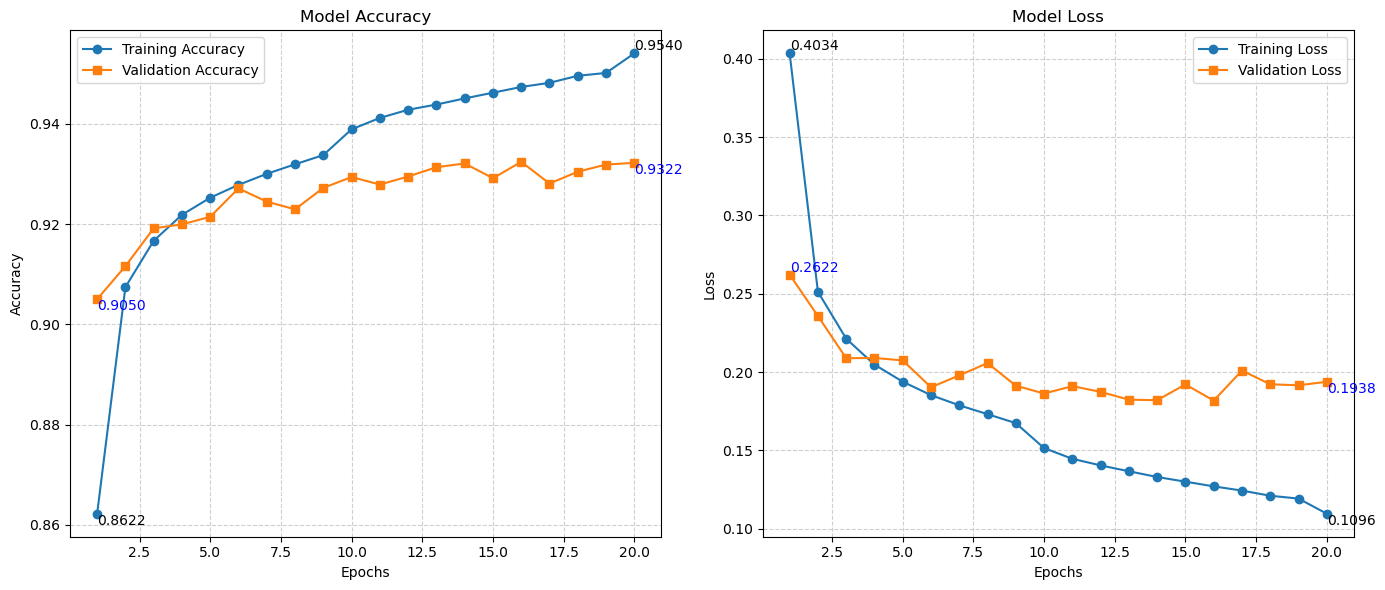

In [163]:
plot_accuracy_loss(model_history)

In [164]:
y_true, y_pred, sample_images, sample_labels, sample_preds = extract_predictions(model, val_dataset, 27)

2025-02-21 17:49:18.045543: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[32,64,7,7]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,7,7]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]}
2025-02-21 17:49:18.168221: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[32,128,4,4]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,4,4]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationFo

Precision: 0.9392
Recall: 0.9290
F1-score: 0.9329


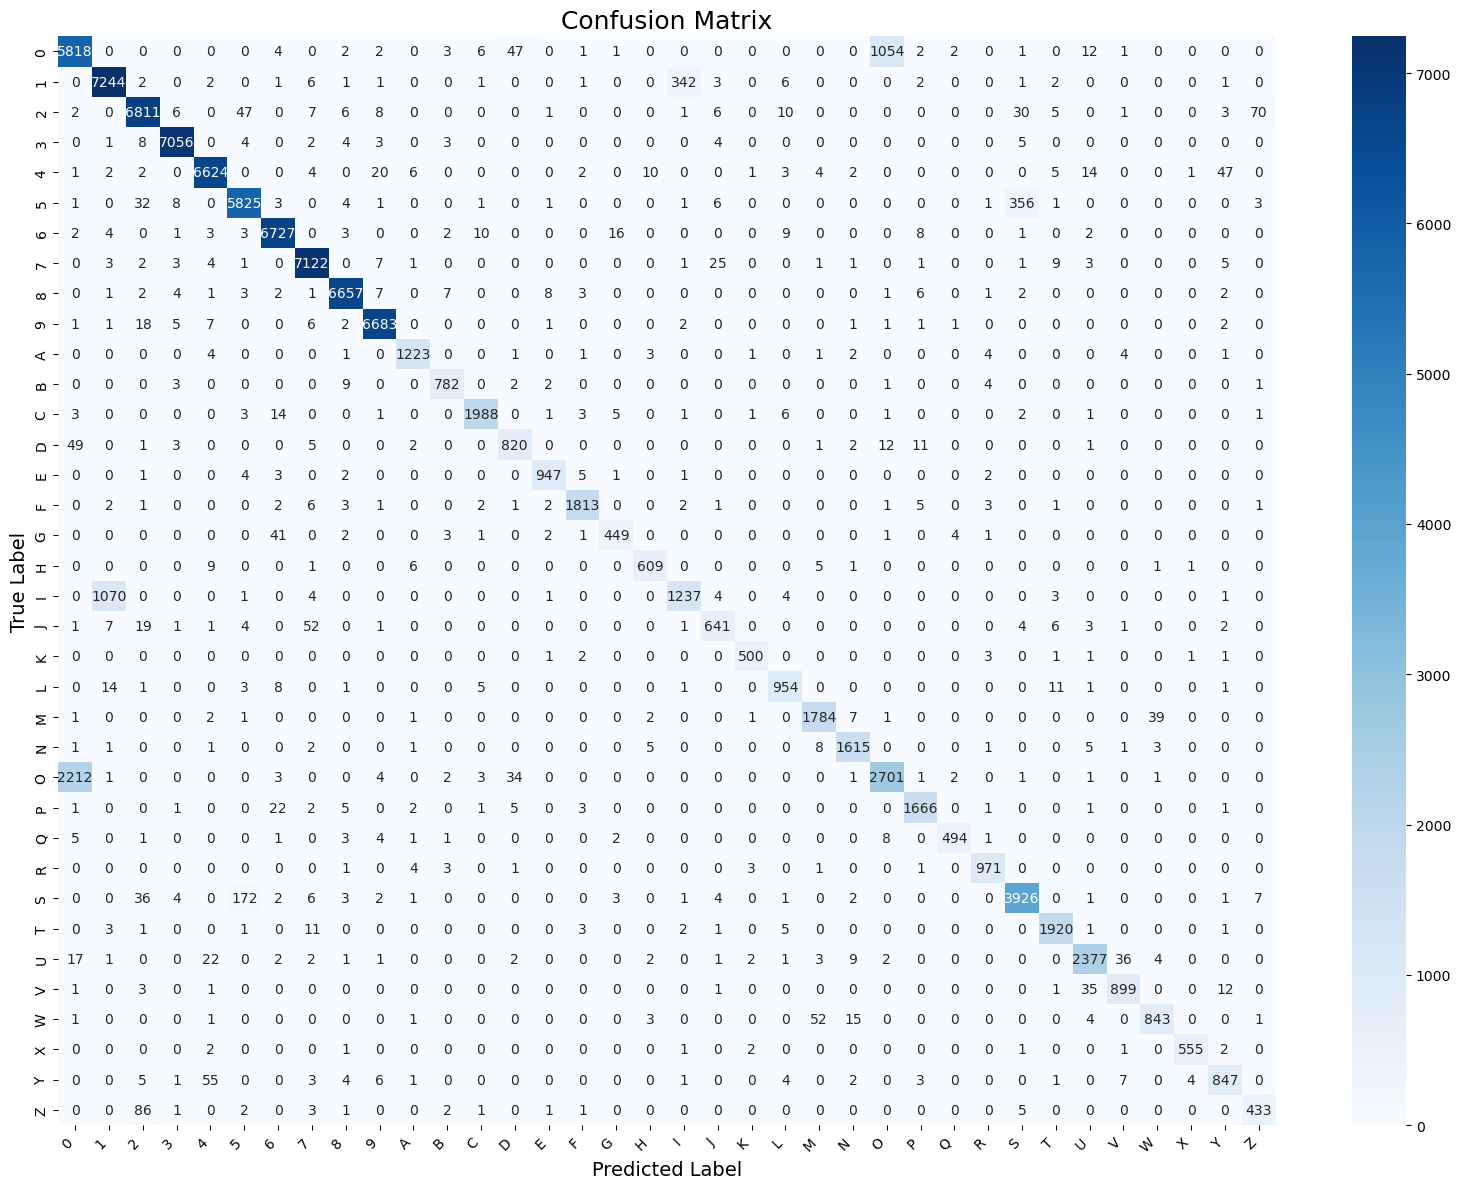

In [165]:
compute_metrics(y_true, y_pred, label_dict)

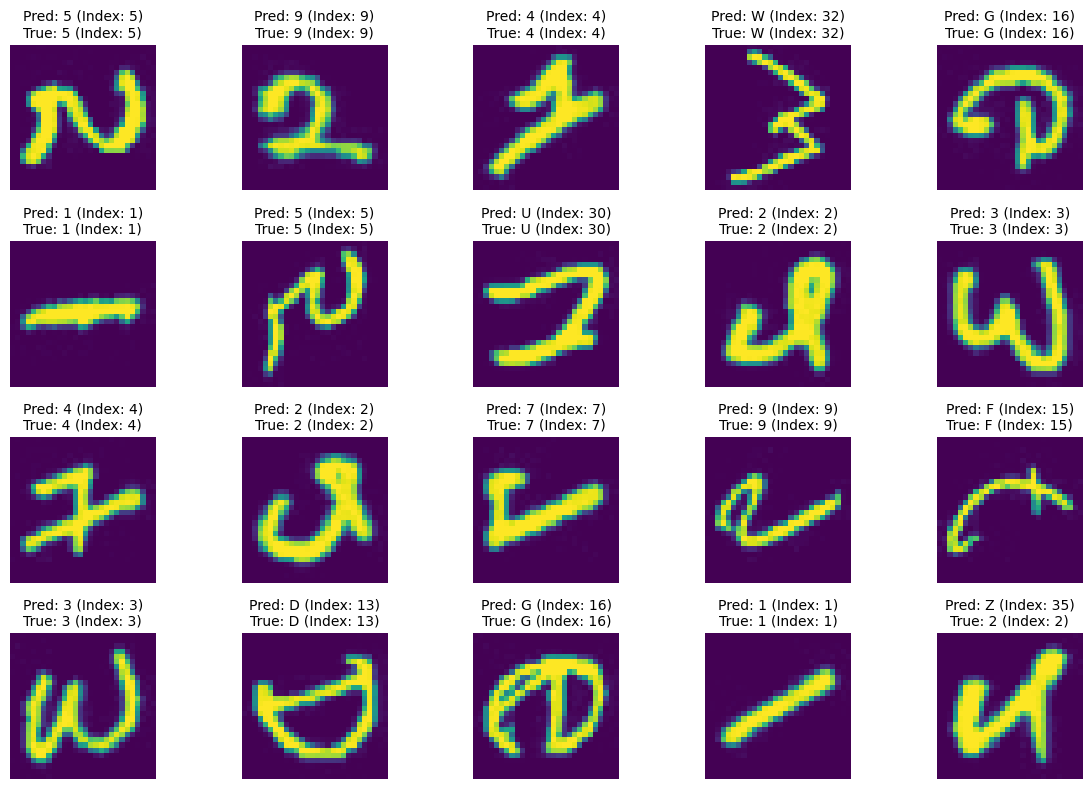

In [166]:
plot_sample_predictions(sample_images, sample_labels, sample_preds, label_dict, 20)